In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<Axes: xlabel='job_title_short'>

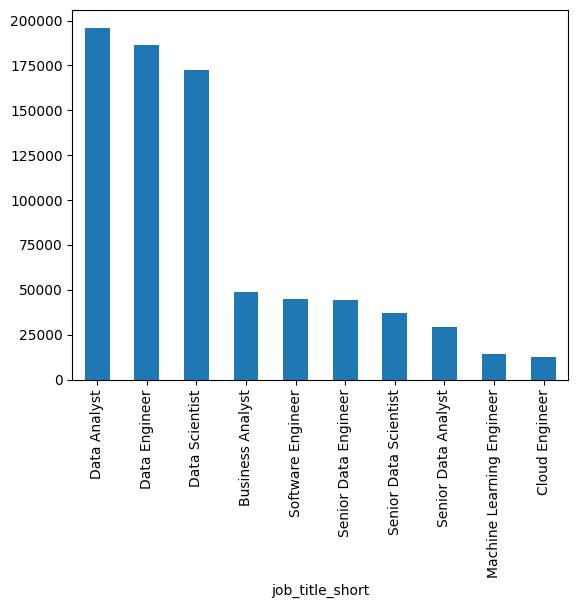

In [2]:
fig,ax=plt.subplots()
df['job_title_short'].value_counts().plot(kind='bar',ax=ax)

In [3]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

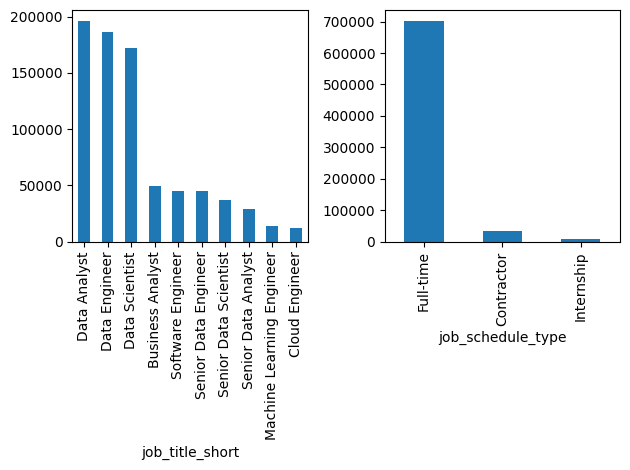

In [6]:
fig,ax=plt.subplots(1,2)
df['job_title_short'].value_counts().plot(kind='bar',ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[1])
fig.tight_layout()

In [7]:
# Create a copy to avoid modifying the original dataframe
df_skills = df.copy()

# Explode the 'job_skills' column (turns lists into individual rows)
df_skills = df_skills.explode('job_skills')

# Group by skill and job title to get the frequency of each pair
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Convert the resulting Series back into a DataFrame and name the count column
df_skills_count = skills_count.reset_index(name='skill_count')

# Sort the results by the highest count first
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

In [5]:
fig.tight_layout()

In [8]:
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [10]:
job_titles=['Data Scientist','Data Engineer','Data Analyst']

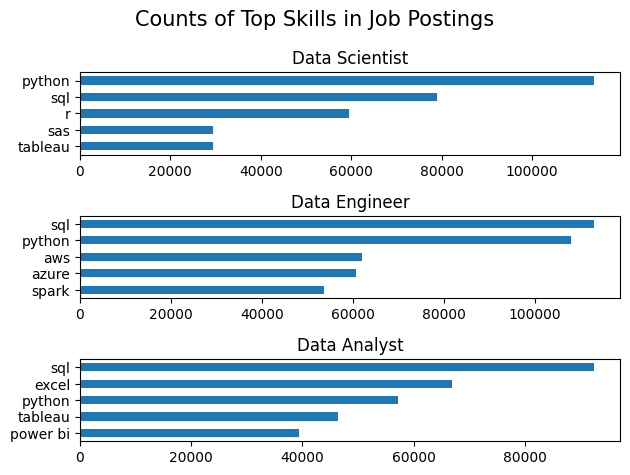

In [19]:
fig,ax=plt.subplots(3,1)
for i, job_title in enumerate(job_titles):
    # Filter the main dataframe for the specific job title and take the top 5 skills
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    
    # Plotting on the specific subplot axis (ax[i])
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    
    # Formatting each subplot
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim() # Usually you'd put a range here, like (0, max_count)

# Adding a main title and cleaning up the layout
fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()